In [ ]:
# Simple News Topic Classifier using TF-IDF + Logistic Regression

import pandas as pd  # load and handle dataset
from sklearn.model_selection import train_test_split  # split data
from sklearn.feature_extraction.text import TfidfVectorizer  # convert text to numbers
from sklearn.linear_model import LogisticRegression  # the classifier
from sklearn.pipeline import Pipeline  # chain TF-IDF and the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # evaluation
import seaborn as sns  # plot
import matplotlib.pyplot as plt  # show plots

### 1. Load dataset

In [ ]:

DATA_PATH = "News_Category_Dataset_v3.json"

def load_data(path):
    df = pd.read_json(path, lines=True)
    # 'headline' as text and 'category' as label
    df = df[['headline', 'category']]
    # Drop any rows with missing values
    df = df.dropna()
    return df

### 2. Simple text preprocessing

In [ ]:
def basic_clean(text):
    # Convert text to lowercase
    return text.lower()

def prepare_data(df):
    # Apply cleaning to each headline
    df['clean_headline'] = df['headline'].apply(basic_clean)
    # X = input texts, y = labels
    X = df['clean_headline'].values
    y = df['category'].values
    return X, y

### 3. Split data into train, validation, and test sets

In [ ]:
def split_data(X, y):
    # First split: train + temp (validation + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    # Second split: validation + test from temp
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

### 4. Build a simple TF-IDF + Logistic Regression pipeline

In [ ]:
def build_model():
    """Create a pipeline that converts text to TF-IDF features and trains Logistic Regression."""
    model = Pipeline([
        # Convert text to TF-IDF features
        ('tfidf', TfidfVectorizer(
            max_features=20000,  
            ngram_range=(1, 2),  # Use unigrams and bigrams
            stop_words='english'  # Remove common stopwords
        )),
        # Logistic Regression classifier
        ('clf', LogisticRegression(
            max_iter=1000,  
            n_jobs=-1       
        ))
    ])
    return model

### 5. Train the model

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val):
    """Train the model and print validation accuracy."""
    model.fit(X_train, y_train)
    # Predict on validation data
    y_val_pred = model.predict(X_val)
    # Compute validation accuracy
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")
    return model

### 6. Evaluate the model on the test set

In [ ]:
def evaluate_model(model, X_test, y_test):
    """Evaluate the model on the test set and print metrics."""
    # Predict labels for test data
    y_pred = model.predict(X_test)
    # Print overall accuracy
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    # Print detailed classification report like precision, recall, F1 per class
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Plot confusion matrix 
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### 7. Simple prediction function for your interactive demo

In [9]:
def predict_topic(model, text):
    """Given a raw text string, return the predicted topic."""
    # Clean the text in the same way as training data
    clean_text = basic_clean(text)
    # Model expects a list/array of texts
    prediction = model.predict([clean_text])[0]
    return prediction

### 8. Main script to run everything

Loaded 209527 headlines.
Train size: 146668, Val size: 31429, Test size: 31430
Validation Accuracy: 0.5742
Test Accuracy: 0.5708

Classification Report:
                precision    recall  f1-score   support

          ARTS       0.46      0.18      0.26       226
ARTS & CULTURE       0.23      0.06      0.09       201
  BLACK VOICES       0.54      0.33      0.41       688
      BUSINESS       0.49      0.43      0.46       899
       COLLEGE       0.54      0.29      0.37       171
        COMEDY       0.61      0.41      0.49       810
         CRIME       0.55      0.51      0.53       535
CULTURE & ARTS       0.70      0.17      0.28       161
       DIVORCE       0.81      0.59      0.69       514
     EDUCATION       0.44      0.22      0.29       152
 ENTERTAINMENT       0.55      0.76      0.64      2605
   ENVIRONMENT       0.61      0.17      0.26       216
         FIFTY       0.57      0.13      0.21       210
  FOOD & DRINK       0.62      0.68      0.65       951
     G

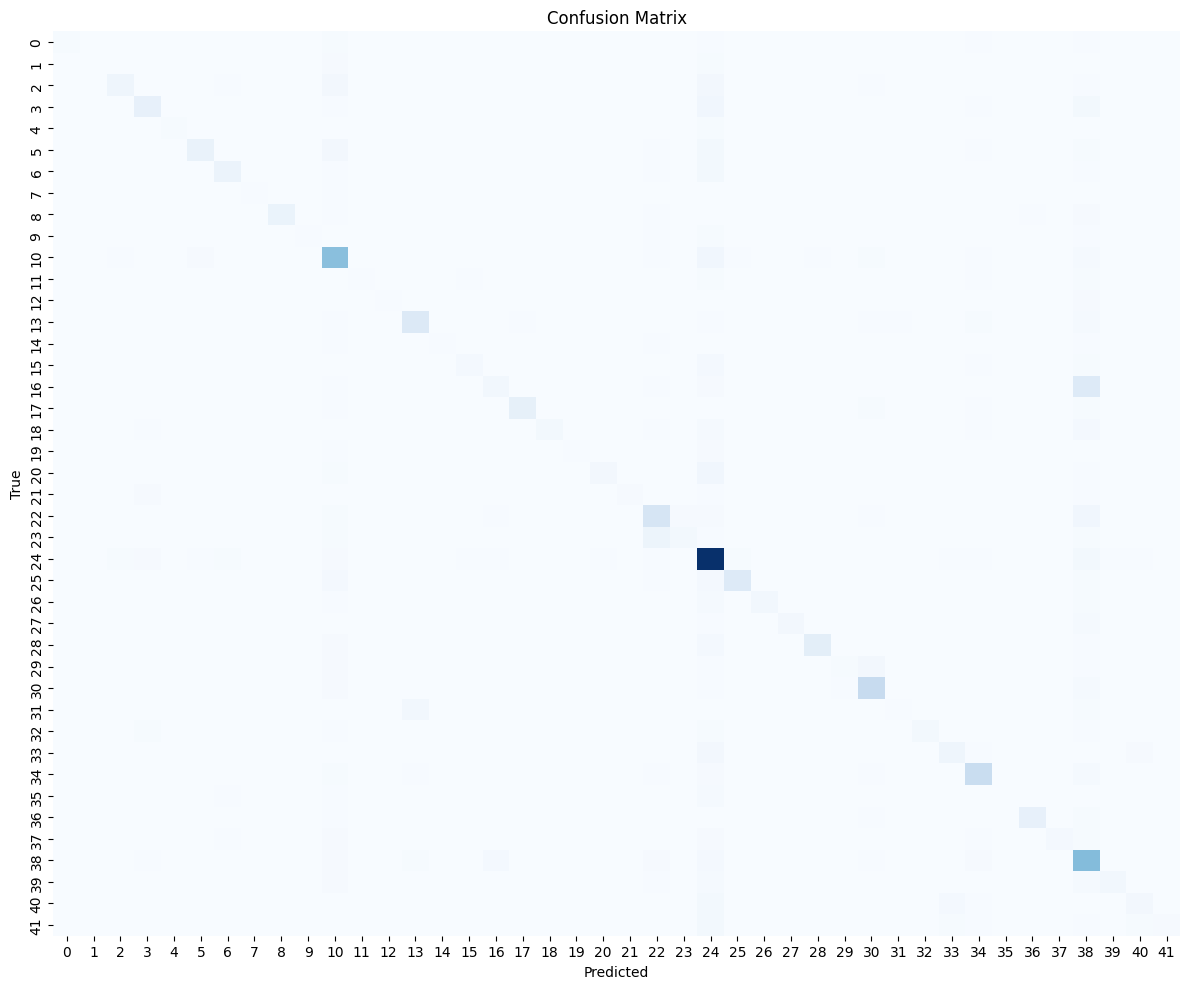


Sample text: Government passes new law on data privacy
Predicted topic: POLITICS


In [ ]:
def main():
    """Run the full pipeline: load data, train model, evaluate, and test."""
    df = load_data(DATA_PATH)
    print(f"Loaded {len(df)} headlines.")
    
    # Prepare data
    X, y = prepare_data(df)
    
    # Split into train/val/test
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")
    
    # Build model
    model = build_model()
    
    # Train model
    model = train_model(model, X_train, y_train, X_val, y_val)
    
    # Evaluate on test set
    evaluate_model(model, X_test, y_test)
    
    # Try a sample prediction
    sample_text = "Government passes new law on data privacy"
    predicted_topic = predict_topic(model, sample_text)
    print(f"\nSample text: {sample_text}")
    print(f"Predicted topic: {predicted_topic}")

if __name__ == "__main__":
    main()